# Week 7: 전이 학습 (Transfer Learning) 및 사전 학습 모델 활용 (2026-05-14)

## 1. 실습 개요
- **학습 목표**: 거대 데이터셋(ImageNet)으로 이미 학습된 모델을 가져와 내 데이터에 맞게 재학습시키는 **전이 학습(Transfer Learning)**의 원리를 이해하고 실습합니다.
- **주요 내용**:
    - 사전 학습 모델(VGG, ResNet 등)의 구조 이해
    - **Feature Extraction** vs **Fine-Tuning** 차이점 학습
    - `torchvision.models`를 이용한 모델 로드 및 수정
    - CIFAR-10 데이터셋에 대한 성능 고도화

---

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor
from torch.optim import lr_scheduler, Adam
from torchvision.datasets import ImageFolder
from torchvision.models import vgg16, VGG16_Weights, resnet34, ResNet34_Weights
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from PIL import Image
import cv2


# from config import CONTENT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.set_printoptions(linewidth=1000)
set_seed(2026)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Colab 한글 폰트 설정
# 이 셀을 먼저 실행하면 matplotlib 그래프의 한글이 깨지지 않습니다.
# !sudo apt-get -qq install fonts-nanum
# !sudo fc-cache -fv
# !rm -rf ~/.cache/matplotlib

# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm

# fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
# plt.rcParams["font.family"] = "NanumGothic"
# plt.rcParams["axes.unicode_minus"] = False

# print("한글 폰트 설정 완료")

In [ ]:
# transform: 크기 통일 + 텐서 변환 + 정규화
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# loader: 모든 이미지를 RGB로 강제 (RGBA 섞이는 것 방지)
dataset = ImageFolder(
    root='./content',
    transform=transform,
    loader=lambda p: Image.open(p).convert('RGB'),
)
print('총 이미지 수:', len(dataset))
print('클래스:', dataset.class_to_idx)

# 8:2로 train/test 분할
train_idx, test_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    random_state=42,
    stratify=dataset.targets,
)
train_set = Subset(dataset, train_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)
print(f'Train: {len(train_set)}장, Test: {len(test_set)}장')

# ImageFolder가 찾은 클래스 개수만큼 마지막 출력 노드를 만듭니다.
num_classes = 4

# 간단한 CNN 모델
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    # 128x128 -> 64x64
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    # 64x64 -> 32x32
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    # 32x32 -> 16x16
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes),
).to(device)

print(model)


총 이미지 수: 238
클래스: {'강호동': 0, '이수지': 1, '차은우': 2, '카리나': 3}
Train: 190장, Test: 48장
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=32768, out_features=256, bias=True)
  (11): ReLU()
  (12): Linear(in_features=256, out_features=4, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss, correct = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    print(f'Epoch {epoch+1:02d} | loss {total_loss/len(train_set):.3f} | acc {correct/len(train_set):.2f}')

KeyboardInterrupt: 

Test 정확도: 0.44
예측: 차은우


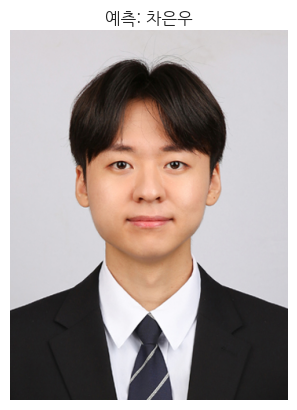

In [ ]:
model.eval()
correct = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
print(f'Test 정확도: {correct/len(test_set):.2f}')

test_image_path = 'content/홍철민.jpg'

img = Image.open(test_image_path).convert('RGB')
x = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred_idx = model(x).argmax(1).item()

classes = list(dataset.class_to_idx.keys())
print('예측:', classes[pred_idx])

plt.imshow(img)
plt.title(f'예측: {classes[pred_idx]}')
plt.axis('off')
plt.show()

## 2. 데이터 전처리 (Pre-trained Model 기준)
- 사전 학습 모델들은 보통 ImageNet의 평균과 표준편차로 정규화되어 있습니다.
- 또한, 모델에 따라 입력 이미지 크기(예: 224x224) 조절이 필요할 수 있습니다.

In [ ]:
# ImageNet 사전학습 모델용 정규화 값 (외울 필요는 없고 그냥 가져다 쓰기)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

dataset = datasets.ImageFolder(
    root='./content',
    transform=transform,
    loader=lambda p: Image.open(p).convert('RGB'),  # RGBA 등 안전하게 RGB 로
)

# 8:2 분할 — stratify 로 4명 비율 유지
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=dataset.targets
)
train_set = Subset(dataset, train_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

classes = dataset.classes
print('클래스:', classes)
print(f'train: {len(train_set)}장 / test: {len(test_set)}장')

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()                          # 학습 모드 (Dropout/BN 활성)
    correct, total = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()              # 이전 step 의 gradient 초기화
        out = model(X)                     # forward
        loss = criterion(out, y)           # 손실 계산
        loss.backward()                    # backward — gradient 구하기
        optimizer.step()                   # 가중치 갱신
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


def evaluate(model, loader):
    model.eval()                           # 평가 모드 (Dropout/BN 비활성)
    correct, total = 0, 0
    with torch.no_grad():                  # 평가 땐 gradient 안 구함
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total


print('학습/평가 함수 정의 완료')

클래스: ['강호동', '이수지', '차은우', '카리나']
train: 190장 / test: 48장
학습/평가 함수 정의 완료


## 3. 사전 학습 모델 로드 및 수정
- `ResNet18`을 사용하여 실습을 진행합니다.

In [ ]:
# 모델 로드 (weights 옵션 사용 권장)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 1. Feature Extraction (가중치 고정)
for param in model.parameters():
    param.requires_grad = False

# 2. 마지막 출력층 수정 (CIFAR-10 클래스는 10개)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 10)

model_fe = model.to(device)

trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_fe.parameters())
print(f'학습 파라미터: {trainable:,} / 전체: {total:,} ({trainable/total*100:.2f}%)')


criterion = nn.CrossEntropyLoss()
optimizer = Adam(model_fe.fc.parameters(), lr=1e-3)

epochs = 10
fe_acc = []
for ep in range(epochs):
    tr = train_one_epoch(model_fe, train_loader, criterion, optimizer)
    te = evaluate(model_fe, test_loader)
    fe_acc.append(te)
    print(f'[FE ep{ep+1}] train_acc={tr:.3f} test_acc={te:.3f}')

학습 파라미터: 5,130 / 전체: 11,181,642 (0.05%)


KeyboardInterrupt: 

In [ ]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 4)
model_ft = model_ft.to(device)

optimizer = Adam(model_ft.parameters(), lr=1e-4)

ft_acc = []
for ep in range(epochs):
    tr = train_one_epoch(model_ft, train_loader, criterion, optimizer)
    te = evaluate(model_ft, test_loader)
    ft_acc.append(te)
    print(f'[FT ep{ep+1}] train_acc={tr:.3f} test_acc={te:.3f}')

[FT ep1] train_acc=0.537 test_acc=0.708
[FT ep2] train_acc=0.947 test_acc=0.854
[FT ep3] train_acc=0.984 test_acc=0.833
[FT ep4] train_acc=1.000 test_acc=0.875
[FT ep5] train_acc=1.000 test_acc=0.896
[FT ep6] train_acc=1.000 test_acc=0.896
[FT ep7] train_acc=1.000 test_acc=0.875
[FT ep8] train_acc=1.000 test_acc=0.854
[FT ep9] train_acc=1.000 test_acc=0.917
[FT ep10] train_acc=1.000 test_acc=0.896


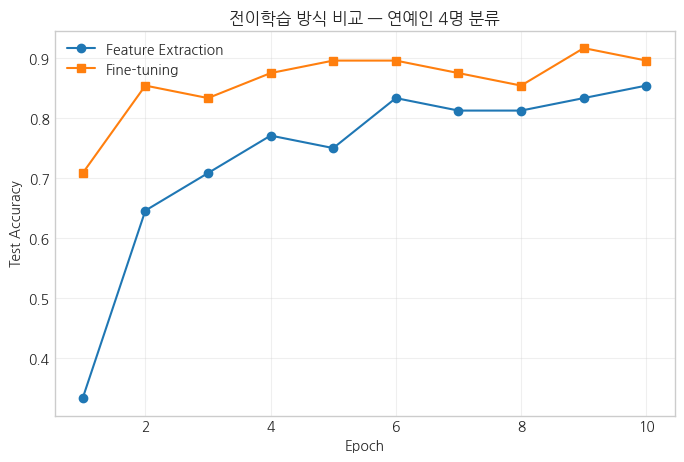

FE 최종: 0.854
FT 최종: 0.896


In [ ]:
# 두 방식 test 정확도 비교
epochs_x = range(1, epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_x, fe_acc, 'o-', label='Feature Extraction')
plt.plot(epochs_x, ft_acc, 's-', label='Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('전이학습 방식 비교 — 연예인 4명 분류')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'FE 최종: {fe_acc[-1]:.3f}')
print(f'FT 최종: {ft_acc[-1]:.3f}')

In [2]:

def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""
    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)

def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()
    total_loss = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device, batch_size=128):
    """검증/테스트 데이터에 대한 평균 loss와 모델 출력값을 반환합니다."""
    model.eval()

    eval_dataset = TensorDataset(x_val_tensor, y_val_tensor)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0
    pred_list = []

    with torch.no_grad():
        for x, y in eval_loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            pred_list.append(pred.cpu())

    eval_loss = total_loss / len(eval_dataset)
    pred = torch.cat(pred_list, dim=0)

    return eval_loss, pred  

def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.plot(epochs, val_acc_list, label="val_acc", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()  

In [ ]:
weights = VGG16_Weights.DEFAULT
preprocess = weights.transforms()

imagenet_mean = preprocess.mean
imagenet_std = preprocess.std

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s] 


In [ ]:

batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_data = test_dataset.data
test_targets = np.array(test_dataset.targets)
# 차원 위치 변경: (N, H, W, C) -> (N, C, H, W)
test_data = test_data.transpose((0, 3, 1, 2))

# 텐서 변환
test_data = torch.tensor(test_data, dtype=torch.float32)
test_targets = torch.tensor(test_targets, dtype=torch.long)

test_data.shape, test_targets.shape
x_val, x_test = test_data[:5000], test_data[5000:]
y_val, y_test = test_targets[:5000], test_targets[5000:]

x_val.shape, y_val.shape, x_test.shape, y_test.shape
def normalize_with_imagenet_stats(x):
    x = x / 255.0
    mean = torch.tensor(imagenet_mean, dtype=torch.float32).view(1, 3, 1, 1)
    std = torch.tensor(imagenet_std, dtype=torch.float32).view(1, 3, 1, 1)
    return (x - mean) / std

x_val = normalize_with_imagenet_stats(x_val)
x_test = normalize_with_imagenet_stats(x_test)

class VGG16(nn.Module):
    def __init__(self, num_classes=1000):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            # 첫 번째 블록
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1), # 1층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1), # 2층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 두 번째 블록
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), # 3층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), # 4층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 세 번째 블록
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), # 5층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1), # 6층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1), # 7층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 네 번째 블록
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1), # 8층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 9층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 10층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 다섯 번째 블록
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 11층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 12층
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1), # 13층
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [ ]:
classes = train_dataset.classes

# 전이학습 모델 선언
# ImageNet 데이터셋(약 120만정의 컬러이미지, 1000개 클래스)으로 사전 학습
model = vgg16(weights=weights)
for param in model.features.parameters():
    param.requires_grad = False

n_class = len(classes)

model.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, n_class),
)

model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(filter(lambda p :p.requires_grad, model.parameters()), lr =1e-4)

epochs = 5
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t + 1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

Epoch 1, train loss : 1.1169, val loss : 0.9437, val acc : 0.6678
Epoch 2, train loss : 0.9392, val loss : 0.9193, val acc : 0.6788
Epoch 3, train loss : 0.8672, val loss : 0.8884, val acc : 0.6866
Epoch 4, train loss : 0.8140, val loss : 0.8755, val acc : 0.6936
Epoch 5, train loss : 0.7642, val loss : 0.8678, val acc : 0.6938


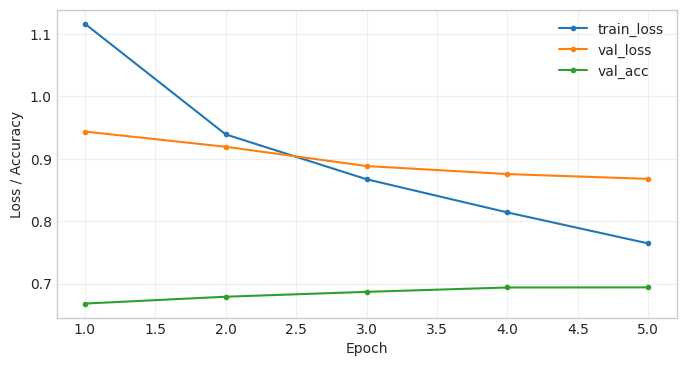

In [10]:
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

In [3]:
weights = ResNet34_Weights.DEFAULT
preprocess = weights.transforms()

imagenet_mean = preprocess.mean
imagenet_std = preprocess.std

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

classes = train_dataset.classes

100%|██████████| 170M/170M [00:05<00:00, 32.7MB/s] 


In [5]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_data = test_dataset.data
test_targets = np.array(test_dataset.targets)

# 차원 위치 변경: (N, H, W, C) -> (N, C, H, W)
test_data = test_data.transpose((0, 3, 1, 2))

# 텐서 변환
test_data = torch.tensor(test_data, dtype=torch.float32)
test_targets = torch.tensor(test_targets, dtype=torch.long)

x_val, x_test = test_data[:5000], test_data[5000:]
y_val, y_test = test_targets[:5000], test_targets[5000:]

def normalize_with_imagenet_stats(x):
    x = x / 255.0
    mean = torch.tensor(imagenet_mean, dtype=torch.float32).view(1, 3, 1, 1)
    std = torch.tensor(imagenet_std, dtype=torch.float32).view(1, 3, 1, 1)
    return (x - mean) / std

x_val = normalize_with_imagenet_stats(x_val)
x_test = normalize_with_imagenet_stats(x_test)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

model = resnet34(weights=weights)
n_class = len(classes)      # 10

# 특징을 보고 최종 정답을 고르는 층
model.fc = nn.Linear(
    in_features = model.fc.in_features,
    out_features = n_class,
    bias=True
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 184MB/s] 


Epoch 1, train loss : 0.1955, val loss : 0.6101, val acc : 0.8198
Epoch 6, train loss : 0.0663, val loss : 0.7056, val acc : 0.8334
Epoch 11, train loss : 0.0424, val loss : 0.8021, val acc : 0.8236
Epoch 16, train loss : 0.0337, val loss : 0.7715, val acc : 0.8400


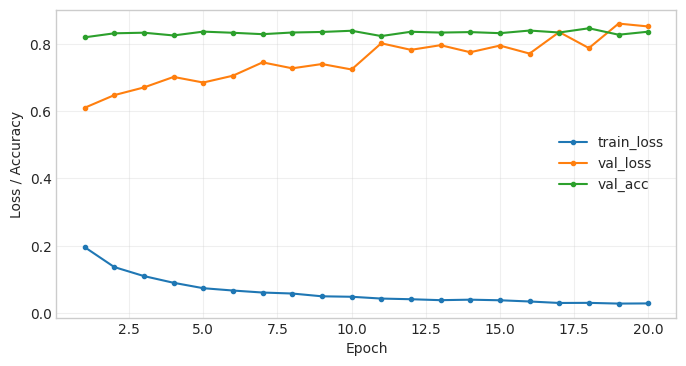

In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.0001)

epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    if t % 5 == 0:
        print(f"Epoch {t + 1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)